In [10]:
!pip install mplfinance

In [11]:
!pip install yfinance

In [12]:
import pandas as pd
import yfinance as yf
import mplfinance as mpf

In [13]:
data = yf.download('AAPL', start='2020-01-01', end='2023-01-01')

[*********************100%***********************]  1 of 1 completed


In [14]:
if isinstance(data, pd.DataFrame):
    print("Data is a DataFrame")

Data is a DataFrame


In [15]:
if isinstance(data.columns, pd.MultiIndex):
    print("Data is a DataFrame")
    data.columns = data.columns.droplevel(1)

Data is a DataFrame


In [16]:
data.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200
2020-01-09,74.568794,74.761457,73.742742,73.993202,170108400
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800
2020-01-13,76.334099,76.360594,74.934866,75.052878,121532000
2020-01-14,75.303307,76.480978,75.180487,76.271455,161954400


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   756 non-null    float64
 1   High    756 non-null    float64
 2   Low     756 non-null    float64
 3   Open    756 non-null    float64
 4   Volume  756 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.4 KB


In [18]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [19]:
data.describe()


Price,Close,High,Low,Open,Volume
count,756.000000,756.000000,756.000000,756.000000,7.560000e+02
mean,127.128754,128.671053,125.473652,127.051112,1.120920e+08
std,30.301250,30.577590,30.020451,30.329239,5.602586e+07
min,54.163700,55.160698,51.324796,55.059309,3.519590e+07
25%,112.264151,113.753656,110.812214,112.443589,7.636470e+07
50%,132.485176,133.613784,130.532821,132.307426,9.493580e+07
75%,147.635803,148.798284,145.698868,147.005552,1.296327e+08
max,177.939728,178.848931,175.114350,178.545866,4.265100e+08


# Exploratory Data Analysis (EDA) on the stock data

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1400x800 with 0 Axes>

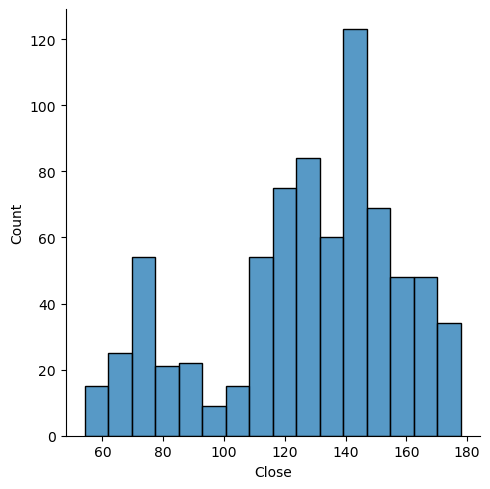

In [21]:
plt.figure(figsize=(14, 8))
sns.displot(data['Close'])
plt.show() 

<Figure size 1400x800 with 0 Axes>

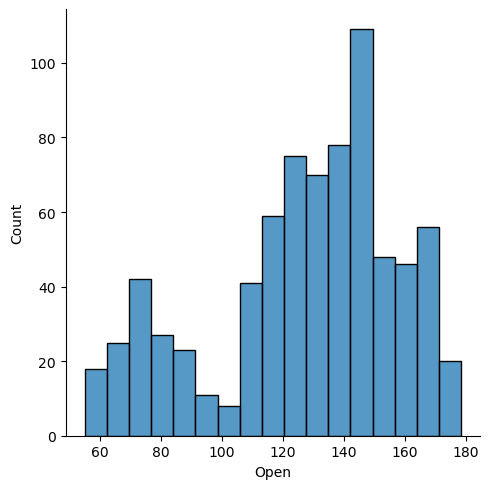

In [22]:
plt.figure(figsize=(14, 8))
sns.displot(data['Open'])
plt.show()

<Figure size 1400x800 with 0 Axes>

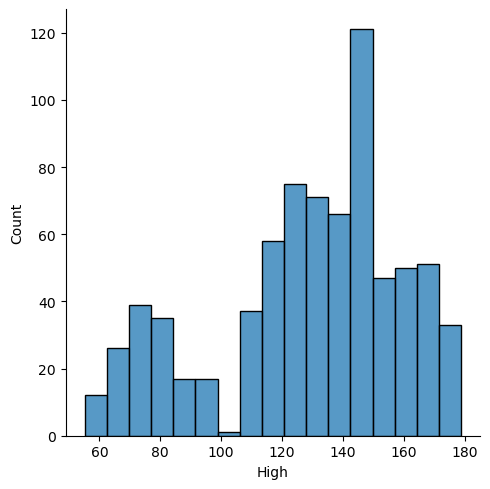

In [23]:
plt.figure(figsize=(14, 8))
sns.displot(data['High'])
plt.show()

<Figure size 1400x800 with 0 Axes>

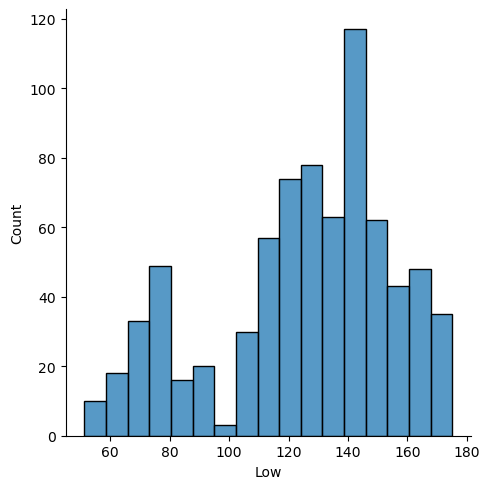

In [24]:
plt.figure(figsize=(14, 8))
sns.displot(data['Low'])
plt.show()

In [25]:
data.head()
type(data['Open'])

pandas.core.series.Series

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   756 non-null    float64
 1   High    756 non-null    float64
 2   Low     756 non-null    float64
 3   Open    756 non-null    float64
 4   Volume  756 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.4 KB


In [27]:
data['Open'] = data['Open'].astype(float)   

/opt/anaconda3/lib/python3.13/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


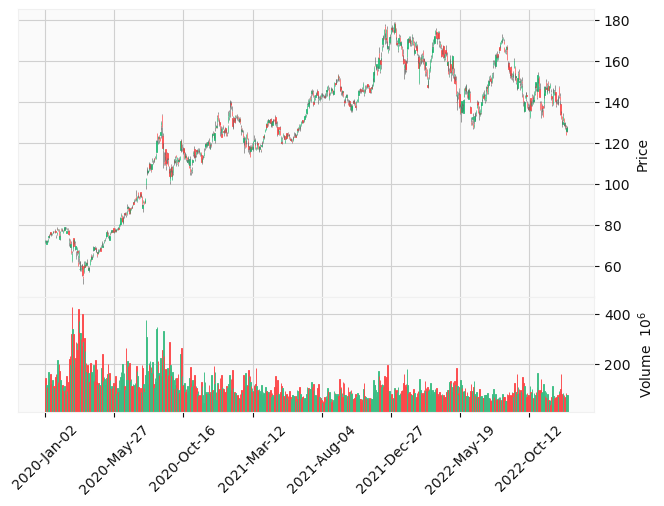

In [28]:
mpf.plot(
    data,
    type="candle",
    volume=True,
    style="yahoo"
)

Text(0.5, 1.0, 'Close Price with 20-Day Moving Average')

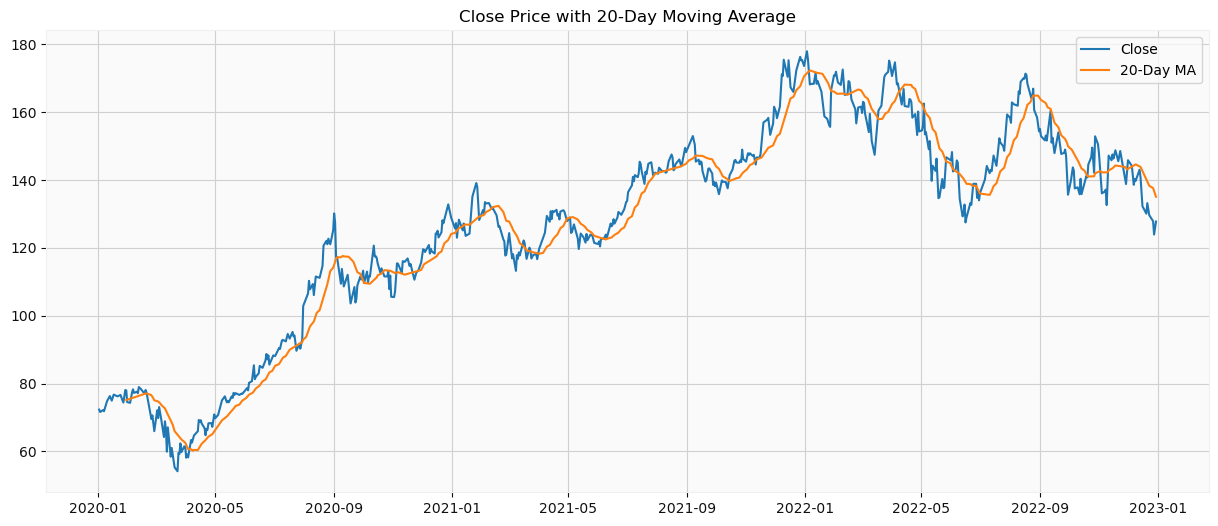

In [29]:
data["MA20"] = data["Close"].rolling(20).mean()

plt.figure(figsize=(15,6))

plt.plot(data.index, data["Close"], label="Close")
plt.plot(data.index, data["MA20"], label="20-Day MA")

plt.legend()
plt.title("Close Price with 20-Day Moving Average")

In [30]:
data['Close']

Date
2020-01-02     72.333878
2020-01-03     71.630630
2020-01-06     72.201424
2020-01-07     71.861847
2020-01-08     73.017830
                 ...    
2022-12-23    129.659393
2022-12-27    127.859932
2022-12-28    123.936539
2022-12-29    127.446945
2022-12-30    127.761627
Name: Close, Length: 756, dtype: float64

## Feature Enginering

In [31]:
data.head(30)

Price,Close,High,Low,Open,Volume,MA20
Date,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800,NaN
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,NaN
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN
2020-01-09,74.568794,74.761457,73.742742,73.993202,170108400,NaN
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN
2020-01-13,76.334099,76.360594,74.934866,75.052878,121532000,NaN
2020-01-14,75.303307,76.480978,75.180487,76.271455,161954400,NaN


In [32]:
data["MA50_Close"] = data["Close"].rolling(50).mean()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,MA50_Close
Date,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800,NaN,NaN
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,NaN,NaN
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN
2020-01-09,74.568794,74.761457,73.742742,73.993202,170108400,NaN,NaN
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN
2020-01-13,76.334099,76.360594,74.934866,75.052878,121532000,NaN,NaN
2020-01-14,75.303307,76.480978,75.180487,76.271455,161954400,NaN,NaN


In [33]:
data['Daily_Return'] = data['Close'].pct_change()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return
Date,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800,NaN,NaN,-0.009722
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,NaN,NaN,0.007969
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.004703
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.016086
2020-01-09,74.568794,74.761457,73.742742,73.993202,170108400,NaN,NaN,0.021241
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN,0.002261
2020-01-13,76.334099,76.360594,74.934866,75.052878,121532000,NaN,NaN,0.021364
2020-01-14,75.303307,76.480978,75.180487,76.271455,161954400,NaN,NaN,-0.013504


## Calendar Features

In [34]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return
Date,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800,NaN,NaN,-0.009722
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,NaN,NaN,0.007969
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.004703
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.016086


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         756 non-null    float64
 1   High          756 non-null    float64
 2   Low           756 non-null    float64
 3   Open          756 non-null    float64
 4   Volume        756 non-null    int64  
 5   MA20          737 non-null    float64
 6   MA50_Close    707 non-null    float64
 7   Daily_Return  755 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 53.2 KB


In [36]:
data.index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2022-12-16', '2022-12-19', '2022-12-20', '2022-12-21',
               '2022-12-22', '2022-12-23', '2022-12-27', '2022-12-28',
               '2022-12-29', '2022-12-30'],
              dtype='datetime64[ns]', name='Date', length=756, freq=None)

In [37]:
data["Day"] = data.index.day

In [38]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return,Day
Date,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,2
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800,NaN,NaN,-0.009722,3
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,NaN,NaN,0.007969,6
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.004703,7
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.016086,8


In [ ]:
data["Weekday"] = data.index.weekday

In [42]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return,Day,Weekday
Date,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,2,3
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800,NaN,NaN,-0.009722,3,4
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,NaN,NaN,0.007969,6,0
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.004703,7,1
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.016086,8,2


In [43]:
data["Month"]= data.index.month

In [44]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return,Day,Weekday,Month
Date,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,2,3,1
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800,NaN,NaN,-0.009722,3,4,1
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,NaN,NaN,0.007969,6,0,1
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.004703,7,1,1
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.016086,8,2,1


In [45]:
data["Year"] = data.index.year

In [46]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return,Day,Weekday,Month,Year
Date,,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,2,3,1,2020
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800,NaN,NaN,-0.009722,3,4,1,2020
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,NaN,NaN,0.007969,6,0,1,2020
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.004703,7,1,1,2020
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.016086,8,2,1,2020
